# Введение в MapReduce модель на Python


In [1]:
from typing import NamedTuple
from typing import Iterator

In [2]:
def MAP(_, row:NamedTuple):
  if (row.gender == 'female'):
    yield (row.age, row)
    
def REDUCE(age:str, rows:Iterator[NamedTuple]):
  sum = 0
  count = 0
  for row in rows:
    sum += row.social_contacts
    count += 1
  if (count > 0):
    yield (age, sum/count)
  else:
    yield (age, 0)

Модель элемента данных

In [3]:
class User(NamedTuple):
  id: int
  age: str
  social_contacts: int
  gender: str

In [4]:
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800)
]

Функция RECORDREADER моделирует чтение элементов с диска или по сети.

In [5]:
def RECORDREADER():
  return [(u.id, u) for u in input_collection]

In [6]:
list(RECORDREADER())

[(0, User(id=0, age=55, social_contacts=20, gender='male')),
 (1, User(id=1, age=25, social_contacts=240, gender='female')),
 (2, User(id=2, age=25, social_contacts=500, gender='female')),
 (3, User(id=3, age=33, social_contacts=800, gender='female'))]

In [7]:
def flatten(nested_iterable):
  for iterable in nested_iterable:
    for element in iterable:
      yield element

In [8]:
map_output = flatten(map(lambda x: MAP(*x), RECORDREADER()))
map_output = list(map_output) # materialize
map_output

[(25, User(id=1, age=25, social_contacts=240, gender='female')),
 (25, User(id=2, age=25, social_contacts=500, gender='female')),
 (33, User(id=3, age=33, social_contacts=800, gender='female'))]

In [9]:
def groupbykey(iterable):
  t = {}
  for (k2, v2) in iterable:
    t[k2] = t.get(k2, []) + [v2]
  return t.items()

In [10]:
shuffle_output = groupbykey(map_output)
shuffle_output = list(shuffle_output)
shuffle_output

[(25,
  [User(id=1, age=25, social_contacts=240, gender='female'),
   User(id=2, age=25, social_contacts=500, gender='female')]),
 (33, [User(id=3, age=33, social_contacts=800, gender='female')])]

In [11]:
reduce_output = flatten(map(lambda x: REDUCE(*x), shuffle_output))
reduce_output = list(reduce_output)
reduce_output

[(25, 370.0), (33, 800.0)]

Все действия одним конвейером!

In [12]:
list(flatten(map(lambda x: REDUCE(*x), groupbykey(flatten(map(lambda x: MAP(*x), RECORDREADER()))))))

[(25, 370.0), (33, 800.0)]

# **MapReduce**
Выделим общую для всех пользователей часть системы в отдельную функцию высшего порядка. Это наиболее простая модель MapReduce, без учёта распределённого хранения данных. 

Пользователь для решения своей задачи реализует RECORDREADER, MAP, REDUCE.

In [13]:
def flatten(nested_iterable):
  for iterable in nested_iterable:
    for element in iterable:
      yield element

def groupbykey(iterable):
  t = {}
  for (k2, v2) in iterable:
    t[k2] = t.get(k2, []) + [v2]
  return t.items()

def MapReduce(RECORDREADER, MAP, REDUCE):
  return flatten(map(lambda x: REDUCE(*x), groupbykey(flatten(map(lambda x: MAP(*x), RECORDREADER())))))

## Спецификация MapReduce



```
f (k1, v1) -> (k2,v2)*
g (k2, v2*) -> (k3,v3)*
 
mapreduce ((k1,v1)*) -> (k3,v3)*
groupby ((k2,v2)*) -> (k2,v2*)*
flatten (e2**) -> e2*
 
mapreduce .map(f).flatten.groupby(k2).map(g).flatten
```




# Примеры

## SQL 

In [14]:
from typing import NamedTuple # requires python 3.6+
from typing import Iterator

class User(NamedTuple):
  id: int
  age: str
  social_contacts: int
  gender: str
    
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800)
]

def MAP(_, row:NamedTuple):
  if (row.gender == 'female'):
    yield (row.age, row)
    
def REDUCE(age:str, rows:Iterator[NamedTuple]):
  sum = 0
  count = 0
  for row in rows:
    sum += row.social_contacts
    count += 1
  if (count > 0):
    yield (age, sum/count)
  else:
    yield (age, 0)
 
def RECORDREADER():
  return [(u.id, u) for u in input_collection]

output = MapReduce(RECORDREADER, MAP, REDUCE)
output = list(output)
output

[(25, 370.0), (33, 800.0)]

## Matrix-Vector multiplication 

In [15]:
from typing import Iterator
import numpy as np

mat = np.ones((5,4))
vec = np.random.rand(4) # in-memory vector in all map tasks

def MAP(coordinates:(int, int), value:int):
  i, j = coordinates
  yield (i, value*vec[j])
 
def REDUCE(i:int, products:Iterator[NamedTuple]):
  sum = 0
  for p in products:
    sum += p
  yield (i, sum)

def RECORDREADER():
  for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
      yield ((i, j), mat[i,j])
      
output = MapReduce(RECORDREADER, MAP, REDUCE)
output = list(output)
output

[(0, np.float64(1.3385454633970926)),
 (1, np.float64(1.3385454633970926)),
 (2, np.float64(1.3385454633970926)),
 (3, np.float64(1.3385454633970926)),
 (4, np.float64(1.3385454633970926))]

## Inverted index 

In [16]:
from typing import Iterator

d1 = "it is what it is"
d2 = "what is it"
d3 = "it is a banana"
documents = [d1, d2, d3]

def RECORDREADER():
  for (docid, document) in enumerate(documents):
    yield ("{}".format(docid), document)
      
def MAP(docId:str, body:str):
  for word in set(body.split(' ')):
    yield (word, docId)
 
def REDUCE(word:str, docIds:Iterator[str]):
  yield (word, sorted(docIds))

output = MapReduce(RECORDREADER, MAP, REDUCE)
output = list(output)
output

[('it', ['0', '1', '2']),
 ('what', ['0', '1']),
 ('is', ['0', '1', '2']),
 ('banana', ['2']),
 ('a', ['2'])]

## WordCount

In [17]:
from typing import Iterator

d1 = """
it is what it is
it is what it is
it is what it is"""
d2 = """
what is it
what is it"""
d3 = """
it is a banana"""
documents = [d1, d2, d3]

def RECORDREADER():
  for (docid, document) in enumerate(documents):
    for (lineid, line) in enumerate(document.split('\n')):
      yield ("{}:{}".format(docid,lineid), line)

def MAP(docId:str, line:str):
  for word in line.split(" "):  
    yield (word, 1)
 
def REDUCE(word:str, counts:Iterator[int]):
  sum = 0
  for c in counts:
    sum += c
  yield (word, sum)

output = MapReduce(RECORDREADER, MAP, REDUCE)
output = list(output)
output

[('', 3), ('it', 9), ('is', 9), ('what', 5), ('a', 1), ('banana', 1)]

# MapReduce Distributed

Добавляется в модель фабрика RECORDREARER-ов --- INPUTFORMAT, функция распределения промежуточных результатов по партициям PARTITIONER, и функция COMBINER для частичной аггрегации промежуточных результатов до распределения по новым партициям.

In [18]:
def flatten(nested_iterable):
  for iterable in nested_iterable:
    for element in iterable:
      yield element

def groupbykey(iterable):
  t = {}
  for (k2, v2) in iterable:
    t[k2] = t.get(k2, []) + [v2]
  return t.items()
      
def groupbykey_distributed(map_partitions, PARTITIONER):
  global reducers
  partitions = [dict() for _ in range(reducers)]
  for map_partition in map_partitions:
    for (k2, v2) in map_partition:
      p = partitions[PARTITIONER(k2)]
      p[k2] = p.get(k2, []) + [v2]
  return [(partition_id, sorted(partition.items(), key=lambda x: x[0])) for (partition_id, partition) in enumerate(partitions)]
 
def PARTITIONER(obj):
  global reducers
  return hash(obj) % reducers
  
def MapReduceDistributed(INPUTFORMAT, MAP, REDUCE, PARTITIONER=PARTITIONER, COMBINER=None):
  map_partitions = map(lambda record_reader: flatten(map(lambda k1v1: MAP(*k1v1), record_reader)), INPUTFORMAT())
  if COMBINER != None:
    map_partitions = map(lambda map_partition: flatten(map(lambda k2v2: COMBINER(*k2v2), groupbykey(map_partition))), map_partitions)
  reduce_partitions = groupbykey_distributed(map_partitions, PARTITIONER) # shuffle
  reduce_outputs = map(lambda reduce_partition: (reduce_partition[0], flatten(map(lambda reduce_input_group: REDUCE(*reduce_input_group), reduce_partition[1]))), reduce_partitions)
  
  print("{} key-value pairs were sent over a network.".format(sum([len(vs) for (k,vs) in flatten([partition for (partition_id, partition) in reduce_partitions])])))
  return reduce_outputs

## Спецификация MapReduce Distributed


```
f (k1, v1) -> (k2,v2)*
g (k2, v2*) -> (k3,v3)*
 
e1 (k1, v1)
e2 (k2, v2)
partition1 (k2, v2)*
partition2 (k2, v2*)*
 
flatmap (e1->e2*, e1*) -> partition1*
groupby (partition1*) -> partition2*

mapreduce ((k1,v1)*) -> (k3,v3)*
mapreduce .flatmap(f).groupby(k2).flatmap(g)
```



## WordCount 

In [19]:
from typing import Iterator
import numpy as np

d1 = """
it is what it is
it is what it is
it is what it is"""
d2 = """
what is it
what is it"""
d3 = """
it is a banana"""
documents = [d1, d2, d3, d1, d2, d3]

maps = 3
reducers = 2

def INPUTFORMAT():
  global maps
  
  def RECORDREADER(split):
    for (docid, document) in enumerate(split):
      for (lineid, line) in enumerate(document.split('\n')):
        yield ("{}:{}".format(docid,lineid), line)
      
  split_size =  int(np.ceil(len(documents)/maps))
  for i in range(0, len(documents), split_size):
    yield RECORDREADER(documents[i:i+split_size])

def MAP(docId:str, line:str):
  for word in line.split(" "):  
    yield (word, 1)
 
def REDUCE(word:str, counts:Iterator[int]):
  sum = 0
  for c in counts:
    sum += c
  yield (word, sum)
  
# try to set COMBINER=REDUCER and look at the number of values sent over the network 
partitioned_output = MapReduceDistributed(INPUTFORMAT, MAP, REDUCE, COMBINER=None) 
partitioned_output = [(partition_id, list(partition)) for (partition_id, partition) in partitioned_output]
partitioned_output

56 key-value pairs were sent over a network.


[(0, [('', 6)]),
 (1, [('a', 2), ('banana', 2), ('is', 18), ('it', 18), ('what', 10)])]

## TeraSort

In [20]:
import numpy as np

input_values = np.random.rand(30)
maps = 3
reducers = 2
min_value = 0.0
max_value = 1.0

def INPUTFORMAT():
  global maps
  
  def RECORDREADER(split):
    for value in split:
        yield (value, None)
      
  split_size =  int(np.ceil(len(input_values)/maps))
  for i in range(0, len(input_values), split_size):
    yield RECORDREADER(input_values[i:i+split_size])
    
def MAP(value:int, _):
  yield (value, None)
  
def PARTITIONER(key):
  global reducers
  global max_value
  global min_value
  bucket_size = (max_value-min_value)/reducers
  bucket_id = 0
  while((key>(bucket_id+1)*bucket_size) and ((bucket_id+1)*bucket_size<max_value)):
    bucket_id += 1
  return bucket_id

def REDUCE(value:int, _):
  yield (None,value)
  
partitioned_output = MapReduceDistributed(INPUTFORMAT, MAP, REDUCE, COMBINER=None, PARTITIONER=PARTITIONER)
partitioned_output = [(partition_id, list(partition)) for (partition_id, partition) in partitioned_output]
partitioned_output

30 key-value pairs were sent over a network.


[(0,
  [(None, np.float64(0.0010590291612500025)),
   (None, np.float64(0.16695818187977374)),
   (None, np.float64(0.17555857189625768)),
   (None, np.float64(0.23527107515569523)),
   (None, np.float64(0.23737340593478107)),
   (None, np.float64(0.26057634120977113)),
   (None, np.float64(0.341421952690254)),
   (None, np.float64(0.3644535767224023)),
   (None, np.float64(0.39186523791823313)),
   (None, np.float64(0.4197443020717395)),
   (None, np.float64(0.4397540657675658)),
   (None, np.float64(0.49698689845546495))]),
 (1,
  [(None, np.float64(0.5577116248919235)),
   (None, np.float64(0.584875913570188)),
   (None, np.float64(0.6206962488894979)),
   (None, np.float64(0.6344439562639741)),
   (None, np.float64(0.6658215108080128)),
   (None, np.float64(0.7408079635594697)),
   (None, np.float64(0.7665749676304371)),
   (None, np.float64(0.7750151794205434)),
   (None, np.float64(0.7868551174854848)),
   (None, np.float64(0.8104095819672044)),
   (None, np.float64(0.81903329475

# Упражнения
Упражнения взяты из Rajaraman A., Ullman J. D. Mining of massive datasets. – Cambridge University Press, 2011.


Для выполнения заданий переопределите функции RECORDREADER, MAP, REDUCE. Для модели распределённой системы может потребоваться переопределение функций PARTITION и COMBINER.

### Максимальное значение ряда

Разработайте MapReduce алгоритм, который находит максимальное число входного списка чисел.

In [21]:
numbers = [5, 12, 3, 89, 34, 89, 7, 23]

def RECORDREADER():
    for i, num in enumerate(numbers):
        yield (i, num)

def MAP(index, value):
    yield ('max', value)

def REDUCE(key, values):
    max_val = float('-inf')
    for v in values:
        if v > max_val:
            max_val = v
    yield (key, max_val)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[('max', 89)]

### Арифметическое среднее

Разработайте MapReduce алгоритм, который находит арифметическое среднее.

$$\overline{X} = \frac{1}{n}\sum_{i=0}^{n} x_i$$


In [22]:
numbers = [10, 20, 30, 40, 50]

def RECORDREADER():
    for i, num in enumerate(numbers):
        yield (i, num)

def MAP(index, value):
    yield ('avg', (value, 1))

def REDUCE(key, values):
    total_sum = 0
    total_count = 0
    for (val, count) in values:
        total_sum += val
        total_count += count
    avg = total_sum / total_count if total_count > 0 else 0
    yield (key, avg)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[('avg', 30.0)]

### GroupByKey на основе сортировки

Реализуйте groupByKey на основе сортировки, проверьте его работу на примерах

In [23]:
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800),
    User(id=4, age=25, gender='male', social_contacts=150),
    User(id=5, age=33, gender='male', social_contacts=300),
]

def MAP(key, row):
    yield (getattr(row, key), row)

def RECORDREADER(attr):
    for u in input_collection:
        yield (attr, u)
        
def groupByKey(iterable):
    sorted_pairs = sorted(iterable, key=lambda x: x[0])
    result = []
    
    for k, v in sorted_pairs:
        if not result or result[-1][0] != k:
            result.append((k, []))
        result[-1][1].append(v)
    
    return result
    
print(list(groupByKey(flatten(map(lambda x: MAP(*x), RECORDREADER("gender"))))))
print(list(groupByKey(flatten(map(lambda x: MAP(*x), RECORDREADER("age"))))))

[('female', [User(id=1, age=25, social_contacts=240, gender='female'), User(id=2, age=25, social_contacts=500, gender='female'), User(id=3, age=33, social_contacts=800, gender='female')]), ('male', [User(id=0, age=55, social_contacts=20, gender='male'), User(id=4, age=25, social_contacts=150, gender='male'), User(id=5, age=33, social_contacts=300, gender='male')])]
[(25, [User(id=1, age=25, social_contacts=240, gender='female'), User(id=2, age=25, social_contacts=500, gender='female'), User(id=4, age=25, social_contacts=150, gender='male')]), (33, [User(id=3, age=33, social_contacts=800, gender='female'), User(id=5, age=33, social_contacts=300, gender='male')]), (55, [User(id=0, age=55, social_contacts=20, gender='male')])]


### Drop duplicates (set construction, unique elements, distinct)

Реализуйте распределённую операцию исключения дубликатов

In [24]:
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=25, gender='male', social_contacts=150),
    User(id=3, age=25, gender='male', social_contacts=150),
]

def RECORDREADER():
    for i, user in enumerate(input_collection):
        yield (i, user)

def MAP(index, user):
    yield (user, index)

def REDUCE(user, values):
    yield (values, user)
    
list(MapReduce(RECORDREADER, MAP, REDUCE))

[([0], User(id=0, age=55, social_contacts=20, gender='male')),
 ([1], User(id=1, age=25, social_contacts=240, gender='female')),
 ([2, 3], User(id=2, age=25, social_contacts=500, gender='female')),
 ([4, 5], User(id=3, age=25, social_contacts=150, gender='male'))]

# Операторы реляционной алгебры
### Selection (Выборка)

**The Map Function**: Для  каждого кортежа $t \in R$ вычисляется истинность предиката $C$. В случае истины создаётся пара ключ-значение $(t, t)$. В паре ключ и значение одинаковы, равны $t$.

**The Reduce Function:** Роль функции Reduce выполняет функция идентичности, которая возвращает то же значение, что получила на вход.

In [25]:
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800),
    User(id=4, age=25, gender='male', social_contacts=150),
    User(id=5, age=33, gender='male', social_contacts=300),
]

def MAP(id, user):
    if user.gender == 'male':
        yield (id, user)

def REDUCE(id, values):
    yield (id, values)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[(0, [User(id=0, age=55, social_contacts=20, gender='male')]),
 (4, [User(id=4, age=25, social_contacts=150, gender='male')]),
 (5, [User(id=5, age=33, social_contacts=300, gender='male')])]

### Projection (Проекция)

Проекция на множество атрибутов $S$.

**The Map Function:** Для каждого кортежа $t \in R$ создайте кортеж $t′$, исключая  из $t$ те значения, атрибуты которых не принадлежат  $S$. Верните пару $(t′, t′)$.

**The Reduce Function:** Для каждого ключа $t′$, созданного любой Map задачей, вы получаете одну или несколько пар $(t′, t′)$. Reduce функция преобразует $(t′, [t′, t′, . . . , t′])$ в $(t′, t′)$, так, что для ключа $t′$ возвращается одна пара  $(t′, t′)$.

In [26]:
class ProjectionUser(NamedTuple):
  id: int
  social_contacts: int

def MAP(id, user):
    pr_user = ProjectionUser(id, user.social_contacts)
    yield (pr_user, pr_user)
    
def REDUCE(pr_user, values):
    yield (pr_user, pr_user)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[(ProjectionUser(id=0, social_contacts=20),
  ProjectionUser(id=0, social_contacts=20)),
 (ProjectionUser(id=1, social_contacts=240),
  ProjectionUser(id=1, social_contacts=240)),
 (ProjectionUser(id=2, social_contacts=500),
  ProjectionUser(id=2, social_contacts=500)),
 (ProjectionUser(id=3, social_contacts=800),
  ProjectionUser(id=3, social_contacts=800)),
 (ProjectionUser(id=4, social_contacts=150),
  ProjectionUser(id=4, social_contacts=150)),
 (ProjectionUser(id=5, social_contacts=300),
  ProjectionUser(id=5, social_contacts=300))]

### Union (Объединение)

**The Map Function:** Превратите каждый входной кортеж $t$ в пару ключ-значение $(t, t)$.

**The Reduce Function:** С каждым ключом $t$ будет ассоциировано одно или два значений. В обоих случаях создайте $(t, t)$ в качестве выходного значения.

In [27]:
R = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
]

S = [
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800),
    User(id=4, age=25, gender='male', social_contacts=150),
]

def RECORDREADER():
    for i, user in enumerate(R):
        yield (i, user)
    for i, user in enumerate(S):
        yield (i, user)

def MAP(id, user):
    yield (user, user)

def REDUCE(user, values):
    yield (user, user)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[(User(id=0, age=55, social_contacts=20, gender='male'),
  User(id=0, age=55, social_contacts=20, gender='male')),
 (User(id=1, age=25, social_contacts=240, gender='female'),
  User(id=1, age=25, social_contacts=240, gender='female')),
 (User(id=2, age=25, social_contacts=500, gender='female'),
  User(id=2, age=25, social_contacts=500, gender='female')),
 (User(id=3, age=33, social_contacts=800, gender='female'),
  User(id=3, age=33, social_contacts=800, gender='female')),
 (User(id=4, age=25, social_contacts=150, gender='male'),
  User(id=4, age=25, social_contacts=150, gender='male'))]

### Intersection (Пересечение)

**The Map Function:** Превратите каждый кортеж $t$ в пары ключ-значение $(t, t)$.

**The Reduce Function:** Если для ключа $t$ есть список из двух элементов $[t, t]$ $-$ создайте пару $(t, t)$. Иначе, ничего не создавайте.

In [28]:
def MAP(id, user):
    yield (user, user)

def REDUCE(user, values):
    if len(values) == 2:
        yield (user, user)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[(User(id=2, age=25, social_contacts=500, gender='female'),
  User(id=2, age=25, social_contacts=500, gender='female'))]

### Difference (Разница)

**The Map Function:** Для кортежа $t \in R$, создайте пару $(t, R)$, и для кортежа $t \in S$, создайте пару $(t, S)$. Задумка заключается в том, чтобы значение пары было именем отношения $R$ or $S$, которому принадлежит кортеж (а лучше, единичный бит, по которому можно два отношения различить $R$ or $S$), а не весь набор атрибутов отношения.

**The Reduce Function:** Для каждого ключа $t$, если соответствующее значение является списком $[R]$, создайте пару $(t, t)$. В иных случаях не предпринимайте действий.

In [29]:
def RECORDREADER():
    for user in R:
        yield (0, user)
    for user in S:
        yield (1, user)

def MAP(id_list, user):
    yield (user, id_list)

def REDUCE(user, values):
    if len(values) == 1 and values[0] == 0:
        yield (user, user)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[(User(id=0, age=55, social_contacts=20, gender='male'),
  User(id=0, age=55, social_contacts=20, gender='male')),
 (User(id=1, age=25, social_contacts=240, gender='female'),
  User(id=1, age=25, social_contacts=240, gender='female'))]

### Natural Join

**The Map Function:** Для каждого кортежа $(a, b)$ отношения $R$, создайте пару $(b,(R, a))$. Для каждого кортежа $(b, c)$ отношения $S$, создайте пару $(b,(S, c))$.

**The Reduce Function:** Каждый ключ $b$ будет асоциирован со списком пар, которые принимают форму либо $(R, a)$, либо $(S, c)$. Создайте все пары, одни, состоящие из  первого компонента $R$, а другие, из первого компонента $S$, то есть $(R, a)$ и $(S, c)$. На выходе вы получаете последовательность пар ключ-значение из списков ключей и значений. Ключ не нужен. Каждое значение, это тройка $(a, b, c)$ такая, что $(R, a)$ и $(S, c)$ это принадлежат входному списку значений.

In [30]:
class UserIdAge(NamedTuple):
    user_id: int
    age: int

class AgeSocialContacts(NamedTuple):
    age: int
    social_contacts: int

class UserFullInfo(NamedTuple):
    user_id: int
    age: int
    social_contacts: int

R = [
    UserIdAge(user_id=10, age=22),
    UserIdAge(user_id=11, age=28),
    UserIdAge(user_id=12, age=22),
    UserIdAge(user_id=13, age=35),
    UserIdAge(user_id=14, age=45),
]

S = [
    AgeSocialContacts(age=22, social_contacts=180),
    AgeSocialContacts(age=22, social_contacts=350),
    AgeSocialContacts(age=28, social_contacts=620),
    AgeSocialContacts(age=35, social_contacts=890),
    AgeSocialContacts(age=50, social_contacts=120),
]

def RECORDREADER():
    for r_tuple in R:
        yield (0, r_tuple)
    for s_tuple in S:
        yield (1, s_tuple)

def MAP(source, tuple_data):
    if source == 0:
        age = tuple_data.age
        user_id = tuple_data.user_id
        yield (age, (0, user_id))
    else:
        age = tuple_data.age
        social_contacts = tuple_data.social_contacts
        yield (age, (1, social_contacts))

def REDUCE(age, values):
    r_values = [user_id for (src, user_id) in values if src == 0]
    s_values = [social_contacts for (src, social_contacts) in values if src == 1]
    
    for user_id in r_values:
        for social_contacts in s_values:
            yield UserFullInfo(user_id=user_id, age=age, social_contacts=social_contacts)

list(MapReduce(RECORDREADER, MAP, REDUCE))

[UserFullInfo(user_id=10, age=22, social_contacts=180),
 UserFullInfo(user_id=10, age=22, social_contacts=350),
 UserFullInfo(user_id=12, age=22, social_contacts=180),
 UserFullInfo(user_id=12, age=22, social_contacts=350),
 UserFullInfo(user_id=11, age=28, social_contacts=620),
 UserFullInfo(user_id=13, age=35, social_contacts=890)]

### Grouping and Aggregation (Группировка и аггрегация)

**The Map Function:** Для каждого кортежа $(a, b, c$) создайте пару $(a, b)$.

**The Reduce Function:** Ключ представляет ту или иную группу. Примение аггрегирующую операцию $\theta$ к списку значений $[b1, b2, . . . , bn]$ ассоциированных с ключом $a$. Возвращайте в выходной поток $(a, x)$, где $x$ результат применения  $\theta$ к списку. Например, если $\theta$ это $SUM$, тогда $x = b1 + b2 + · · · + bn$, а если $\theta$ is $MAX$, тогда $x$ это максимальное из значений $b1, b2, . . . , bn$.

In [31]:
input_collection = [
    User(id=0, age=55, gender='male', social_contacts=20),
    User(id=1, age=25, gender='female', social_contacts=240),
    User(id=2, age=25, gender='female', social_contacts=500),
    User(id=3, age=33, gender='female', social_contacts=800),
    User(id=4, age=25, gender='male', social_contacts=150),
    User(id=5, age=33, gender='male', social_contacts=300),
]

def RECORDREADER():
    for i, user in enumerate(input_collection):
        yield (i, user)
        
def MAP(id, user):
    yield (user.gender, user.social_contacts)
    
def REDUCE(gender, values):
    yield (gender, sum(values))
    
list(MapReduce(RECORDREADER, MAP, REDUCE))

[('male', 470), ('female', 1540)]

### Matrix-Vector multiplication

Случай, когда вектор не помещается в памяти Map задачи

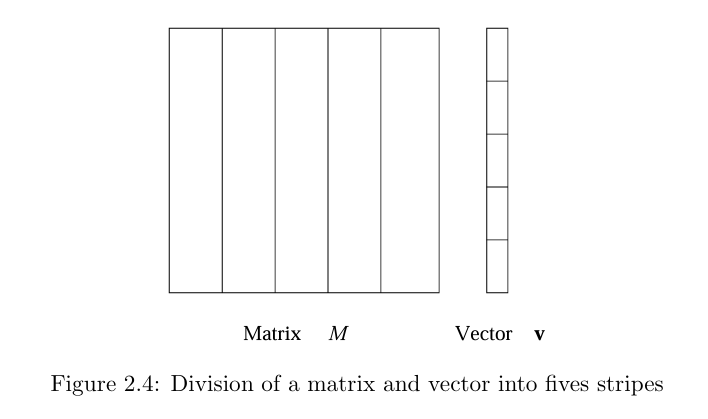


In [32]:
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16],
    [17, 18, 19, 20]
])

vector = np.array([1, 2, 3, 4])

num_stripes = 2
maps = num_stripes
reducers = 2

def INPUTFORMAT():
    global num_stripes, maps
    
    cols_per_stripe = matrix.shape[1] // num_stripes
    
    for stripe_id in range(num_stripes):
        j_start = stripe_id * cols_per_stripe
        j_end = (stripe_id + 1) * cols_per_stripe
        vector_stripe = vector[j_start:j_end]
        
        def RECORDREADER():
            for i in range(matrix.shape[0]):
                for j in range(j_start, j_end):
                    v_idx = j - j_start
                    yield ((i, j), (matrix[i, j], vector_stripe[v_idx]))
        
        yield RECORDREADER()

def MAP(coordinates, values):
    i, j = coordinates
    matrix_value, vector_value = values
    yield (i, matrix_value * vector_value)

def REDUCE(i, products):
    yield (i, sum(products))

partitioned_output = MapReduceDistributed(INPUTFORMAT, MAP, REDUCE)

final_result = []
for partition_id, partition in partitioned_output:
    for res in partition:
        final_result.append(res)

sorted(final_result, key=lambda x: x[0])

20 key-value pairs were sent over a network.


[(0, np.int64(30)),
 (1, np.int64(70)),
 (2, np.int64(110)),
 (3, np.int64(150)),
 (4, np.int64(190))]

Проверка:

In [33]:
np.matmul(matrix, vector)

array([ 30,  70, 110, 150, 190])

## Matrix multiplication (Перемножение матриц)

Если у нас есть матрица $M$ с элементами $m_{ij}$ в строке $i$ и столбце $j$, и матрица $N$ с элементами $n_{jk}$ в строке $j$ и столбце $k$, тогда их произведение $P = MN$ есть матрица $P$ с элементами $p_{ik}$ в строке $i$ и столбце $k$, где

$$p_{ik} =\sum_{j} m_{ij}n_{jk}$$

Необходимым требованием является одинаковое количество столбцов в $M$ и строк в $N$, чтобы операция суммирования по  $j$ была осмысленной. Мы можем размышлять о матрице, как об отношении с тремя атрибутами: номер строки, номер столбца, само значение. Таким образом матрица $M$ предстваляется как отношение $ M(I, J, V )$, с кортежами $(i, j, m_{ij})$, и, аналогично, матрица $N$ представляется как отношение $N(J, K, W)$, с кортежами $(j, k, n_{jk})$. Так как большие матрицы как правило разреженные (большинство значений равно 0), и так как мы можем нулевыми значениями пренебречь (не хранить), такое реляционное представление достаточно эффективно для больших матриц. Однако, возможно, что координаты $i$, $j$, и $k$ неявно закодированы в смещение позиции элемента относительно начала файла, вместо явного хранения. Тогда, функция Map (или Reader) должна быть разработана таким образом, чтобы реконструировать компоненты $I$, $J$, и $K$ кортежей из смещения.

Произведение $MN$ это фактически join, за которым следуют группировка по ключу и аггрегация. Таким образом join отношений $M(I, J, V )$ и $N(J, K, W)$, имеющих общим только атрибут $J$, создаст кортежи $(i, j, k, v, w)$ из каждого кортежа $(i, j, v) \in M$ и кортежа $(j, k, w) \in N$. Такой 5 компонентный кортеж представляет пару элементов матрицы $(m_{ij} , n_{jk})$. Что нам хотелось бы получить на самом деле, это произведение этих элементов, то есть, 4 компонентный кортеж$(i, j, k, v \times w)$, так как он представляет произведение $m_{ij}n_{jk}$. Мы представляем отношение как результат одной MapReduce операции, в которой мы можем произвести группировку и аггрегацию, с $I$ и $K$  атрибутами, по которым идёт группировка, и суммой  $V \times W$. 





In [34]:
# MapReduce model
def flatten(nested_iterable):
  for iterable in nested_iterable:
    for element in iterable:
      yield element

def groupbykey(iterable):
  t = {}
  for (k2, v2) in iterable:
    t[k2] = t.get(k2, []) + [v2]
  return t.items()

def MapReduce(RECORDREADER, MAP, REDUCE):
  return flatten(map(lambda x: REDUCE(*x), groupbykey(flatten(map(lambda x: MAP(*x), RECORDREADER())))))

Реализуйте перемножение матриц с использованием модельного кода MapReduce для одной машины в случае, когда одна матрица хранится в памяти, а другая генерируется RECORDREADER-ом.

In [35]:
import numpy as np
I = 2
J = 3
K = 4*10
small_mat = np.random.rand(I,J) # it is legal to access this from RECORDREADER, MAP, REDUCE
big_mat = np.random.rand(J,K)

def RECORDREADER():
  for j in range(big_mat.shape[0]):
    for k in range(big_mat.shape[1]):
      yield ((j,k), big_mat[j,k])
      
def MAP(k1, v1):
  (j, k) = k1
  w = v1
  for i in range(I):
        yield ((i, k), small_mat[i, j] * w)
  
def REDUCE(key, values):
  yield (key, sum(values))

Проверьте своё решение

In [36]:
# CHECK THE SOLUTION
reference_solution = np.matmul(small_mat, big_mat) 
solution = MapReduce(RECORDREADER, MAP, REDUCE)

def asmatrix(reduce_output):
  reduce_output = list(reduce_output)
  I = max(i for ((i,k), vw) in reduce_output)+1
  K = max(k for ((i,k), vw) in reduce_output)+1
  mat = np.empty(shape=(I,K))
  for ((i,k), vw) in reduce_output:
    mat[i,k] = vw
  return mat

np.allclose(reference_solution, asmatrix(solution)) # should return true

True

In [37]:
reduce_output = list(MapReduce(RECORDREADER, MAP, REDUCE))
max(i for ((i,k), vw) in reduce_output)

1

Реализуйте перемножение матриц  с использованием модельного кода MapReduce для одной машины в случае, когда обе матрицы генерируются в RECORDREADER. Например, сначала одна, а потом другая.

In [38]:
def RECORDREADER():
  for i in range(I):
    for j in range(J):
      for k in range(K):
        yield (((i, j), small_mat[i, j]),((j, k), big_mat[j, k]))

def MAP(mat1, mat2):
  (k1, v1) = mat1
  (k2, v2) = mat2
  yield ((k1[0], k2[1]), v1 * v2)

# CHECK THE SOLUTION
reference_solution = np.matmul(small_mat, big_mat) 
solution = MapReduce(RECORDREADER, MAP, REDUCE)
np.allclose(reference_solution, asmatrix(solution)) # should return true

True

Реализуйте перемножение матриц с использованием модельного кода MapReduce Distributed, когда каждая матрица генерируется в своём RECORDREADER. 

In [39]:
M = np.random.rand(I, J)
N = np.random.rand(J, K)

maps = 2
reducers = 2

def INPUTFORMAT():
    global maps, M, N
    
    def RECORDREADER_M():
        for i in range(I):
            for j in range(J):
                yield ('M', i, j, M[i, j])
    
    def RECORDREADER_N():
        for j in range(J):
            for k in range(K):
                yield ('N', j, k, N[j, k])
    
    yield RECORDREADER_M()
    yield RECORDREADER_N()

def MAP(source, coord1, coord2, value):
    if source == 'M':
        i, j = coord1, coord2
        yield (j, ('M', i, value))
    else:
        j, k = coord1, coord2
        yield (j, ('N', k, value))

def REDUCE(j, values):
    m_vals = [(i, v) for (src, i, v) in values if src == 'M']
    n_vals = [(k, w) for (src, k, w) in values if src == 'N']
    
    for i, v in m_vals:
        for k, w in n_vals:
            yield ((i, k), v * w)

phase1_output = MapReduceDistributed(INPUTFORMAT, MAP, REDUCE, COMBINER=None)

partial_products = []
for partition_id, partition in phase1_output:
    for (key, value) in partition:
        partial_products.append((key, value))

126 key-value pairs were sent over a network.


In [40]:
def INPUTFORMAT_AGG():
    def RECORDREADER_PARTIALS(split):
        for key, value in split:
            yield (key, value)
    
    split_size = int(np.ceil(len(partial_products) / maps))
    for idx in range(0, len(partial_products), split_size):
        yield RECORDREADER_PARTIALS(partial_products[idx:idx+split_size])

def MAP_AGG(key, value):
    yield (key, value)

def REDUCE_AGG(key, values):
    yield (key, sum(values))

phase2_output = MapReduceDistributed(INPUTFORMAT_AGG, MAP_AGG, REDUCE_AGG, COMBINER=None)

solution = []
for partition_id, partition in phase2_output:
    for (key, value) in partition:
        solution.append((key, value))

240 key-value pairs were sent over a network.


In [41]:
# CHECK THE SOLUTION
reference_solution = np.matmul(M, N)
np.allclose(reference_solution, asmatrix(solution)) # should return true

True

Обобщите предыдущее решение на случай, когда каждая матрица генерируется несколькими RECORDREADER-ами, и проверьте его работоспособность. Будет ли работать решение, если RECORDREADER-ы будут генерировать случайное подмножество элементов матрицы?

In [42]:
M = np.random.rand(I, J)
N = np.random.rand(J, K)

def INPUTFORMAT():
    global maps, M, N
    
    m_elements = [(i, j, M[i, j]) for i in range(M.shape[0]) for j in range(M.shape[1])]
    n_elements = [(j, k, N[j, k]) for j in range(N.shape[0]) for k in range(N.shape[1])]
    
    split_size_m = int(np.ceil(len(m_elements) / maps))
    split_size_n = int(np.ceil(len(n_elements) / maps))
    
    def RECORDREADER_M(split):
        for i, j, value in split:
            yield ('M', i, j, value)
    
    def RECORDREADER_N(split):
        for j, k, value in split:
            yield ('N', j, k, value)
    
    for idx in range(0, len(m_elements), split_size_m):
        yield RECORDREADER_M(m_elements[idx:idx+split_size_m])
    
    for idx in range(0, len(n_elements), split_size_n):
        yield RECORDREADER_N(n_elements[idx:idx+split_size_n])

phase1_output = MapReduceDistributed(INPUTFORMAT, MAP, REDUCE, COMBINER=None)

partial_products = []
for partition_id, partition in phase1_output:
    for (key, value) in partition:
        partial_products.append((key, value))
        
phase2_output = MapReduceDistributed(INPUTFORMAT_AGG, MAP_AGG, REDUCE_AGG, COMBINER=None)

solution = []
for partition_id, partition in phase2_output:
    for (key, value) in partition:
        solution.append((key, value))

126 key-value pairs were sent over a network.
240 key-value pairs were sent over a network.


In [43]:
# CHECK THE SOLUTION
reference_solution = np.matmul(M, N)
np.allclose(reference_solution, asmatrix(solution)) # should return true

True

**Будет ли работать решение, если RECORDREADER-ы будут генерировать случайное подмножество элементов матрицы?**

Да, решение будет работать корректно, поскольку в данной реализации MapReduce каждый элемент матрицы передаётся вместе со своими явными координатами, а не выводится неявно из позиции в потоке данных. При генерации случайного подмножества отсутствующие элементы просто не участвуют в вычислениях, что математически эквивалентно их равенству нулю: так как умножение на ноль и сложение с нулем не влияют на итоговую сумму произведений, результат для существующих элементов будет вычислен верно. Это стандартный и эффективный подход для обработки разреженных матриц в распределённых системах, позволяющий игнорировать нулевые значения без потери точности. 

Результат будет отличаться от умножения полных матриц, но это правильное поведение